In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


# RFM Segmentation — PM Analysis

## Business problem
An e-commerce company has transaction records for thousands of customers.
Which customers are most valuable? Which are about to churn?
Which should we reactivate? Which should we let go?

## What is RFM?
- **Recency** — how recently did they buy? (lower days = better)
- **Frequency** — how many times did they buy? (higher = better)
- **Monetary** — how much did they spend in total? (higher = better)

## Key PM question
Which customers deserve our most expensive retention efforts
— and which should we stop spending on?

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')

print("=== DATASET OVERVIEW ===")
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Countries: {df['Country'].nunique()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique products: {df['StockCode'].nunique():,}")

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATASET OVERVIEW ===
Rows: 541,909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Date range: 1/10/2011 10:04 to 9/9/2011 9:52
Countries: 38
Unique customers: 4,372
Unique products: 4,070

=== FIRST 5 ROWS ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  Unite

In [3]:
# Drop rows with no CustomerID — can't do RFM without knowing who bought
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

# Remove returns (negative quantities) and bad prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Parse date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date — day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"After cleaning: {len(df):,} rows")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Reference date for recency: {reference_date.date()}")
print(f"Total revenue in dataset: £{df['Revenue'].sum():,.0f}")

After cleaning: 397,884 rows
Unique customers: 4,338
Reference date for recency: 2011-12-10
Total revenue in dataset: £8,911,408


In [4]:
# Calculate R, F, M per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("=== RFM TABLE (first 10 customers) ===")
print(rfm.head(10).to_string(index=False))

print("\n=== RFM STATISTICS ===")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

print("\n=== PM INTERPRETATION ===")
print(f"Avg days since last purchase:  {rfm['Recency'].mean():.0f} days")
print(f"Avg number of orders:          {rfm['Frequency'].mean():.1f}")
print(f"Avg total spend per customer:  £{rfm['Monetary'].mean():.0f}")
print(f"Top 10% spend threshold:       £{rfm['Monetary'].quantile(0.9):,.0f}")
print(f"Customers with only 1 order:   {(rfm['Frequency']==1).sum():,} ({(rfm['Frequency']==1).mean():.1%})")

=== RFM TABLE (first 10 customers) ===
 CustomerID  Recency  Frequency  Monetary
      12346      326          1  77183.60
      12347        2          7   4310.00
      12348       75          4   1797.24
      12349       19          1   1757.55
      12350      310          1    334.40
      12352       36          8   2506.04
      12353      204          1     89.00
      12354      232          1   1079.40
      12355      214          1    459.40
      12356       23          3   2811.43

=== RFM STATISTICS ===
       Recency  Frequency  Monetary
count   4338.0     4338.0    4338.0
mean      92.5        4.3    2054.3
std      100.0        7.7    8989.2
min        1.0        1.0       3.8
25%       18.0        1.0     307.4
50%       51.0        2.0     674.5
75%      142.0        5.0    1661.7
max      374.0      209.0  280206.0

=== PM INTERPRETATION ===
Avg days since last purchase:  93 days
Avg number of orders:          4.3
Avg total spend per customer:  £2054
Top 10% spend

In [5]:
# Score each dimension 1-5 (5 = best)
# Recency: lower days = better = higher score
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['Total_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Assign PM segment names based on scores
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 3 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("=== SEGMENT DISTRIBUTION ===")
seg_summary = rfm.groupby('Segment').agg(
    count      = ('CustomerID', 'count'),
    avg_recency   = ('Recency',   'mean'),
    avg_frequency = ('Frequency', 'mean'),
    avg_monetary  = ('Monetary',  'mean'),
    total_revenue = ('Monetary',  'sum')
).round(1).sort_values('total_revenue', ascending=False)
seg_summary['pct_customers'] = (seg_summary['count'] / len(rfm) * 100).round(1)
seg_summary['pct_revenue']   = (seg_summary['total_revenue'] / rfm['Monetary'].sum() * 100).round(1)
print(seg_summary.to_string())

=== SEGMENT DISTRIBUTION ===
                     count  avg_recency  avg_frequency  avg_monetary  total_revenue  pct_customers  pct_revenue
Segment                                                                                                        
Champions              962         12.9           11.1        6038.8      5809341.1           22.2         65.2
Loyal Customers        758         35.7            4.1        1842.6      1396691.4           17.5         15.7
At Risk                454        141.6            3.8        1634.7       742150.0           10.5          8.3
Need Attention         781        123.6            1.5         704.0       549851.9           18.0          6.2
Lost                   824        228.5            1.0         230.3       189770.9           19.0          2.1
New Customers          319         18.5            1.2         458.2       146166.6            7.4          1.6
Potential Loyalists    240         29.0            2.4         322.7       

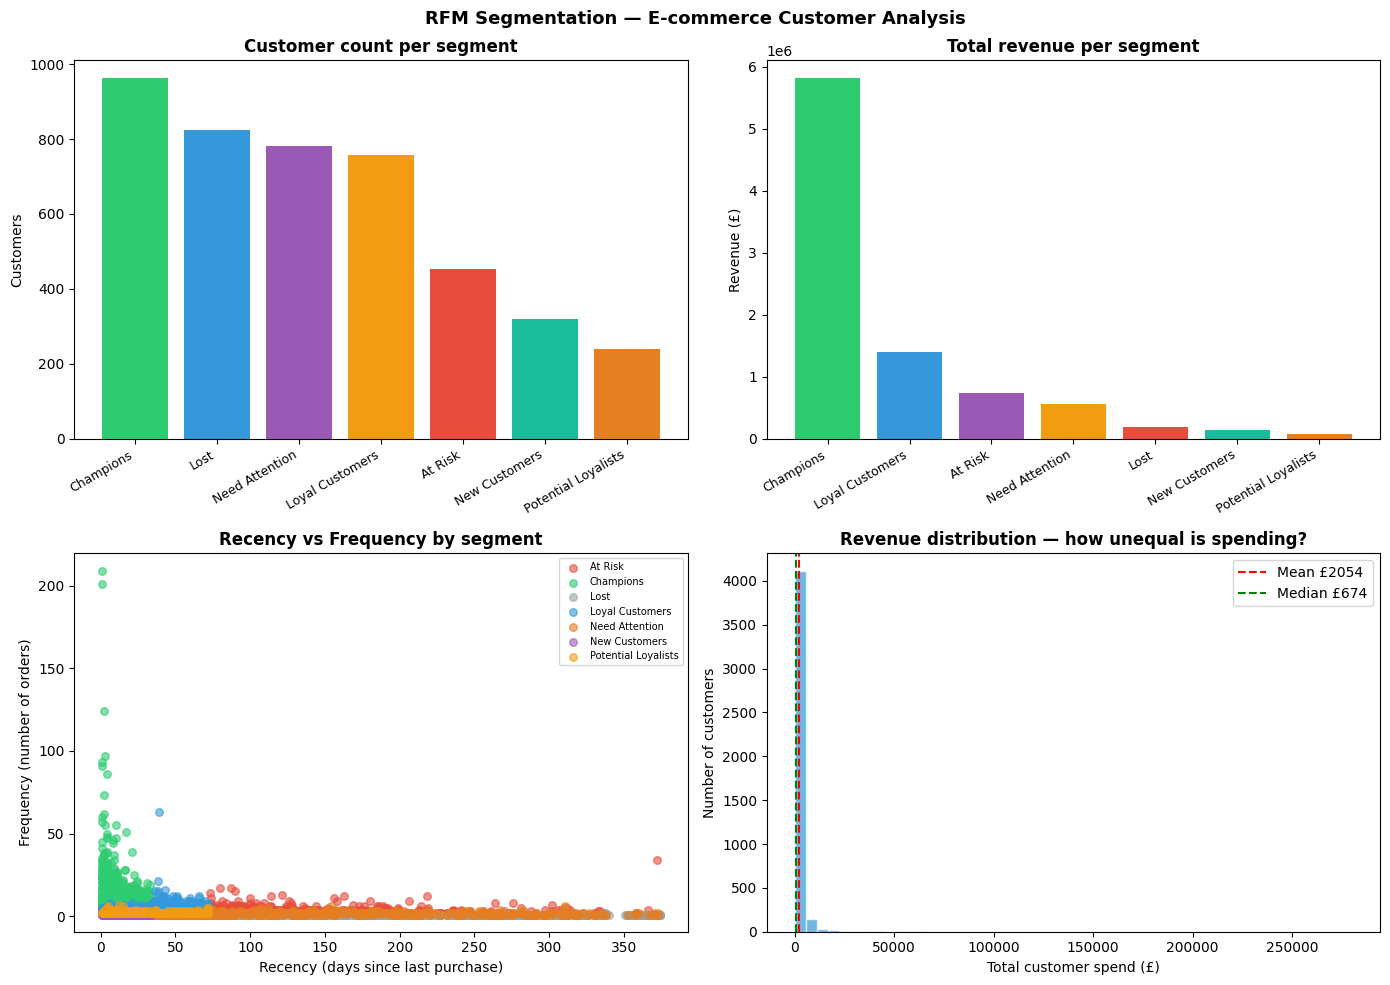

Charts saved!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Customer count per segment
seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#9b59b6','#f39c12','#e74c3c','#1abc9c','#e67e22','#95a5a6']
axes[0,0].bar(range(len(seg_counts)), seg_counts.values, color=colors[:len(seg_counts)])
axes[0,0].set_xticks(range(len(seg_counts)))
axes[0,0].set_xticklabels(seg_counts.index, rotation=30, ha='right', fontsize=9)
axes[0,0].set_title('Customer count per segment', fontweight='bold')
axes[0,0].set_ylabel('Customers')

# Chart 2: Revenue per segment
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].bar(range(len(seg_rev)), seg_rev.values, color=colors[:len(seg_rev)])
axes[0,1].set_xticks(range(len(seg_rev)))
axes[0,1].set_xticklabels(seg_rev.index, rotation=30, ha='right', fontsize=9)
axes[0,1].set_title('Total revenue per segment', fontweight='bold')
axes[0,1].set_ylabel('Revenue (£)')

# Chart 3: Recency vs Frequency scatter coloured by segment
segment_colors = {
    'Champions':'#2ecc71', 'Loyal Customers':'#3498db',
    'New Customers':'#9b59b6', 'Potential Loyalists':'#f39c12',
    'At Risk':'#e74c3c', 'Cant Lose Them':'#1abc9c',
    'Lost':'#95a5a6', 'Need Attention':'#e67e22'
}
for seg, group in rfm.groupby('Segment'):
    axes[1,0].scatter(group['Recency'], group['Frequency'],
                      c=segment_colors.get(seg,'#333'),
                      label=seg, alpha=0.6, s=30)
axes[1,0].set_xlabel('Recency (days since last purchase)')
axes[1,0].set_ylabel('Frequency (number of orders)')
axes[1,0].set_title('Recency vs Frequency by segment', fontweight='bold')
axes[1,0].legend(fontsize=7, loc='upper right')

# Chart 4: Revenue distribution
axes[1,1].hist(rfm['Monetary'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[1,1].axvline(rfm['Monetary'].mean(),   color='red',   linestyle='--', label=f'Mean £{rfm["Monetary"].mean():.0f}')
axes[1,1].axvline(rfm['Monetary'].median(), color='green', linestyle='--', label=f'Median £{rfm["Monetary"].median():.0f}')
axes[1,1].set_xlabel('Total customer spend (£)')
axes[1,1].set_ylabel('Number of customers')
axes[1,1].set_title('Revenue distribution — how unequal is spending?', fontweight='bold')
axes[1,1].legend()

plt.suptitle('RFM Segmentation — E-commerce Customer Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

# RFM Segmentation — Final Summary & PM Insights

---

## Dataset
- 4,338 unique customers
- Average recency: 93 days since last purchase
- Average frequency: 4.3 orders per customer
- Average spend: £2,054 per customer
- Top 10% spend threshold: £3,647
- Single-order customers: 1,493 (34.4%) — biggest revenue leak

---

## Segment Distribution

| Segment | Customers | % of Customers | Avg Recency | Avg Frequency | Avg Spend | Total Revenue | % of Revenue |
|---------|-----------|---------------|-------------|---------------|-----------|---------------|--------------|
| Champions | 962 | 22.2% | 13 days | 11.1 orders | £6,039 | £5,809,341 | 65.2% |
| Loyal Customers | 758 | 17.5% | 36 days | 4.1 orders | £1,843 | £1,396,691 | 15.7% |
| At Risk | 454 | 10.5% | 142 days | 3.8 orders | £1,635 | £742,150 | 8.3% |
| Need Attention | 781 | 18.0% | 124 days | 1.5 orders | £704 | £549,852 | 6.2% |
| Lost | 824 | 19.0% | 229 days | 1.0 orders | £230 | £189,771 | 2.1% |
| New Customers | 319 | 7.4% | 18 days | 1.2 orders | £458 | £146,167 | 1.6% |
| Potential Loyalists | 240 | 5.5% | 29 days | 2.4 orders | £323 | £77,436 | 0.9% |

---

## The Pareto Insight

> Champions = 22.2% of customers = 65.2% of total revenue.
> Champions + Loyal Customers = 39.7% of customers = 80.9% of revenue.
> This is your 80/20 rule confirmed by data.

Stop treating all customers the same.
Your top 40% of customers generate 81% of your revenue.
Every pound of marketing budget should protect them first.

---

## Key Findings

**Finding 1 — Champions dominate revenue disproportionately**
962 customers (22%) generate £5.8M out of £8.9M total — 65% of all revenue.
Average spend: £6,039. Average orders: 11.1. Last purchase: 13 days ago.
These customers are active, loyal, and highly valuable.

**Finding 2 — At Risk segment is your most urgent problem**
454 customers who used to buy frequently (3.8 orders avg) and spend well (£1,635 avg)
have not purchased in 142 days on average. They are slipping away.
Total revenue at stake: £742,150. This is recoverable — but only with immediate action.

**Finding 3 — Lost segment is largely unrecoverable**
824 customers. Average last purchase: 229 days ago. Average spend: £230.
One order, never came back. Cost of reactivation likely exceeds revenue.
One reactivation email — if no response, stop spending.

**Finding 4 — 34.4% of customers placed only 1 order**
1,493 customers bought once and disappeared.
This is your biggest structural problem. The second purchase is the hardest.
A strong onboarding sequence after the first order could move this significantly.

**Finding 5 — New Customers need immediate nurturing**
319 customers bought recently (18 days ago) but only 1.2 times.
They are at the highest risk of becoming Lost.
The window to convert them to Loyal Customers is the next 30 days.

---

## Product Roadmap by Segment

| Priority | Segment | Action | What to build | Success metric |
|---------|---------|--------|---------------|----------------|
| P0 | Champions | RETAIN | VIP programme · Early access · Exclusive offers · Personal thank you | Churn rate below 3% · Repeat purchase rate stays above 90% |
| P0 | At Risk | WIN BACK | Personal outreach · We miss you campaign · Limited time offer · 20% discount | Reactivation rate above 25% within 30 days |
| P1 | Loyal Customers | UPSELL | Premium tier invitation · Bundle offers · Referral programme | Avg order value up 15% · Referral conversion above 10% |
| P1 | New Customers | CONVERT | Onboarding email sequence · Second purchase incentive · Category recommendation | Second purchase rate above 40% within 30 days |
| P2 | Potential Loyalists | NURTURE | Targeted category campaigns · Loyalty points · Frequency incentives | Order frequency from 2.4 to 4.0 within 90 days |
| P2 | Need Attention | ENGAGE | Limited time offers · Browsing reminders · Category-specific campaigns | Purchase within 60 days for 30% of segment |
| P3 | Lost | REACTIVATE | One reactivation email only · If no response stop spending | Any response rate above 5% justifies the send |

---

## What NOT to do

- Do NOT send the same campaign to all 4,338 customers
- Do NOT spend equal budget on Champions and Lost customers — ROI gap is enormous
- Do NOT ignore the At Risk segment — £742,150 in revenue is actively walking out the door
- Do NOT let New Customers go 30 days without a second touchpoint
- Do NOT run win-back campaigns on Lost segment more than once — diminishing returns

---

## The single most important action

> Protect your Champions before acquiring new customers.
> 962 customers generate 65% of your revenue.
> Losing 10% of them costs more than acquiring 500 new customers.
> Build the VIP programme this sprint — everything else can wait.